# Section 4.3

## Example 4.3.1

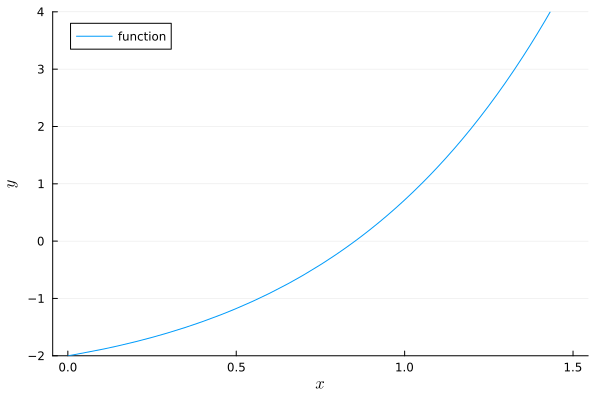

In [16]:
using Plots, LaTeXStrings

f(x) = x * exp(x) - 2
plot(f, 0, 1.5; 
    label="function",  legend=:topleft,
    grid=:y,  ylim=[-2, 4],  xlabel=L"x",  ylabel=L"y")

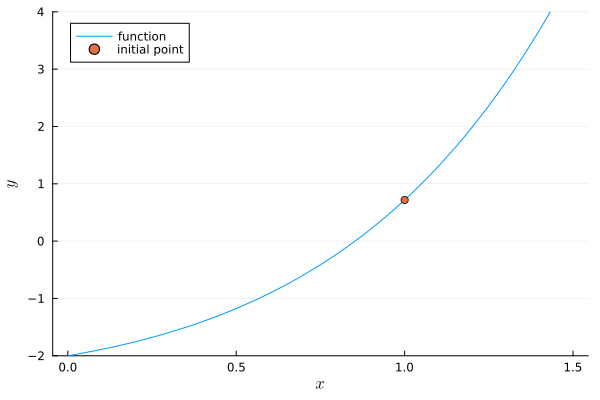

In [17]:
x₁ = 1
y₁ = f(x₁)
scatter!([x₁], [y₁], label="initial point")

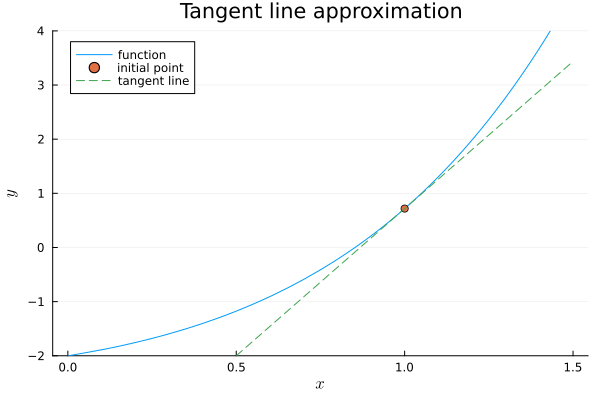

In [18]:
df_dx(x) = exp(x) * (x + 1)
m₁ = df_dx(x₁)
tangent = x -> y₁ + m₁ * (x - x₁)

plot!(tangent, 0, 1.5, l=:dash, label="tangent line",
    title="Tangent line approximation")

In [19]:
x₂ = x₁ - y₁ / m₁


0.8678794411714423

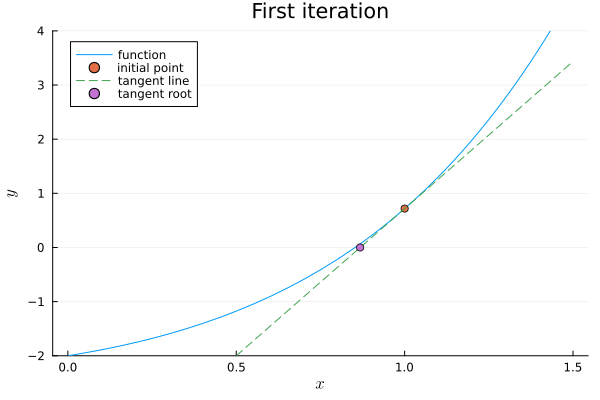

In [20]:
scatter!([x₂], [0], label="tangent root", title="First iteration")

In [21]:
y₂ = f(x₂)

0.06716266657572145

x₃ = x₂ - y₂ / m₂ = 0.8527833734164099


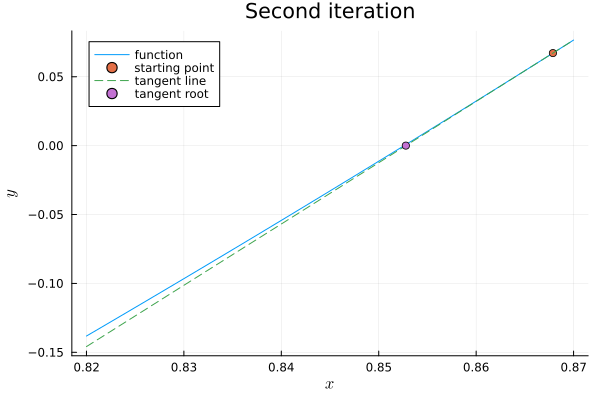

In [ ]:
plot(f, 0.82, 0.87;
    label="function",  legend=:topleft,
    xlabel=L"x",  ylabel=L"y",
    title="Second iteration")

scatter!([x₂], [y₂], label="starting point")

m₂ = df_dx(x₂)
tangent = x -> y₂ + m₂ * (x - x₂)
plot!(tangent, 0.82, 0.87; l=:dash, label="tangent line")

In [23]:
x₃ = x₂ - y₂ / m₂


0.8527833734164099

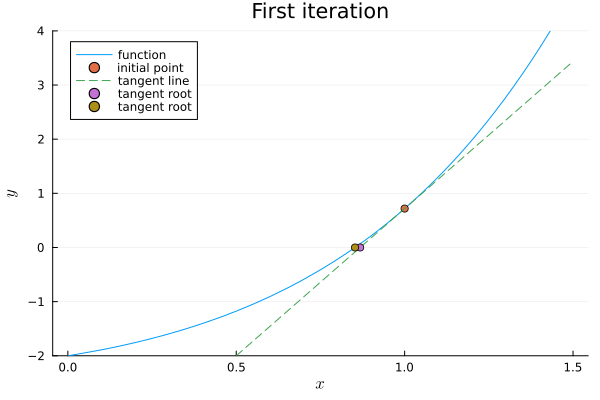

In [24]:
scatter!([x₃], [0], label="tangent root")

In [7]:
y₃ = f(x₃)

0.0007730906446230534

## Example 4.3.2

In [8]:
f(x) = x * exp(x) - 2;
df_dx(x) = exp(x) * (x + 1);

In [9]:
using NLsolve
r = nlsolve(x -> f(x[1]), [1.0]).zero

1-element Vector{Float64}:
 0.852605502013726

In [10]:
x = [1; zeros(4)]
for k = 1:4
    x[k+1] = x[k] - f(x[k]) / df_dx(x[k])
end
x

5-element Vector{Float64}:
 1.0
 0.8678794411714423
 0.8527833734164099
 0.8526055263689221
 0.852605502013726

In [11]:
ϵ = @. x - r

5-element Vector{Float64}:
 0.14739449798627402
 0.015273939157716354
 0.00017787140268388235
 2.435519608212644e-8
 0.0

In [12]:
x = [BigFloat(1); zeros(7)]
for k = 1:7
    x[k+1] = x[k] - f(x[k]) / df_dx(x[k])
end
r = x[end]

0.8526055020137254913464724146953174668984533001514035087721073946525150656742605

In [13]:
ϵ = @. Float64(x[1:end-1] - r)

7-element Vector{Float64}:
 0.14739449798627452
 0.01527393915771683
 0.00017787140268443004
 2.435519656311045e-8
 4.56680051680793e-16
 1.6056572825272187e-31
 1.9848810119594387e-62

In [14]:
using PrettyTables

logerr = @. log10(abs(ϵ))
ratios = [NaN; [logerr[i+1] / logerr[i] for i in 1:length(logerr)-1]]
pretty_table( (iter=1:7, ϵ, logerr, ratios);
    column_labels=["iteration", "error", "log error", "ratio"], backend=:html )

iteration,error,log error,ratio
1,0.147394,-0.831519,NaN
2,0.0152739,-1.81605,2.18401
3,0.000177871,-3.74989,2.06486
4,2.43552e-8,-7.61341,2.0303
5,4.5668e-16,-15.3404,2.01492
6,1.60566e-31,-30.7943,2.0074
7,1.98488e-62,-61.7023,2.00369


## Example 4.3.3

In [ ]:
using FNCFunctions

g(x) = exp(x) - x
dg_dx(x) = exp(x) - 1;


dg_dx (generic function with 1 method)

$$x = g^{-1}(y) \implies g(x) = y \implies g(x) - y = 0$$

In [26]:

y = range(g(0), g(2), 200)
x = zeros(length(y))

for (i, y) in enumerate(y)
    f(x) = g(x) - y
    df_dx(x) = dg_dx(x)
    r = FNC.newton(f, df_dx, y)
    x[i] = r[end]
end


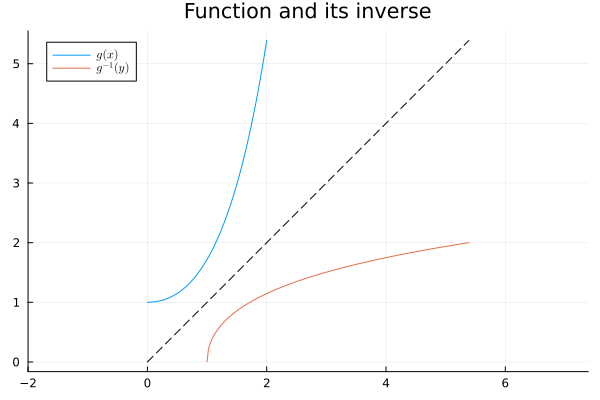

In [27]:
using Plots, LaTeXStrings
plot(g, 0, 2, aspect_ratio=1, label=L"g(x)")
plot!(y, x, label=L"g^{-1}(y)", title="Function and its inverse")
plot!(x -> x, 0, maximum(y), label="", l=(:dash, 1), color=:black)